In [1]:
import pandas as pd
import matplotlib

In [4]:
df_test = pd.read_csv('amazon_reviews/test.csv')
df_train = pd.read_csv('amazon_reviews/train.csv')

In [5]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   class_index   400000 non-null  int64
 1   review_title  399976 non-null  str  
 2   review_text   400000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 9.2 MB


In [8]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column        Dtype
---  ------        -----
 0   class_index   int64
 1   review_title  str  
 2   review_text   str  
dtypes: int64(1), str(2)
memory usage: 82.4 MB


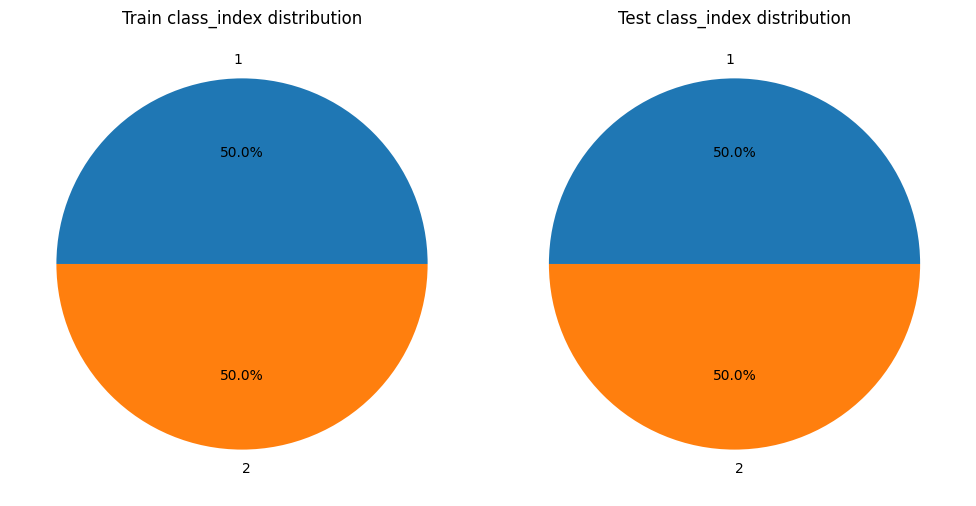

In [9]:
import matplotlib.pyplot as plt

# Count class distribution
train_counts = df_train['class_index'].value_counts().sort_index()
test_counts = df_test['class_index'].value_counts().sort_index()

# Create side-by-side pies
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%')
axes[0].set_title('Train class_index distribution')

axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%')
axes[1].set_title('Test class_index distribution')

plt.tight_layout()
plt.show()

In [18]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column        Dtype
---  ------        -----
 0   label         int64
 1   review_title  str  
 2   text          str  
dtypes: int64(1), str(2)
memory usage: 82.4 MB


# Preprocessing

In [24]:
df_train.rename(columns={'class_index':'label'}, inplace=True)
df_train.rename(columns={'review_text':'text'}, inplace=True)
df_train.drop('review_title', axis=1, inplace=True,errors='ignore')
df_train['label']-=1 # 0 - negative review, 1 - positive review

In [27]:
df_test.rename(columns={'class_index':'label'}, inplace=True)
df_test.rename(columns={'review_text':'text'}, inplace=True)
df_test.drop('review_title', axis=1, inplace=True,errors='ignore')
df_test['label']-=1 # 0 - negative review, 1 - positive review

In [28]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   400000 non-null  int64
 1   text    400000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 6.1 MB


In [29]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   label   int64
 1   text    str  
dtypes: int64(1), str(1)
memory usage: 54.9 MB


# Distribution

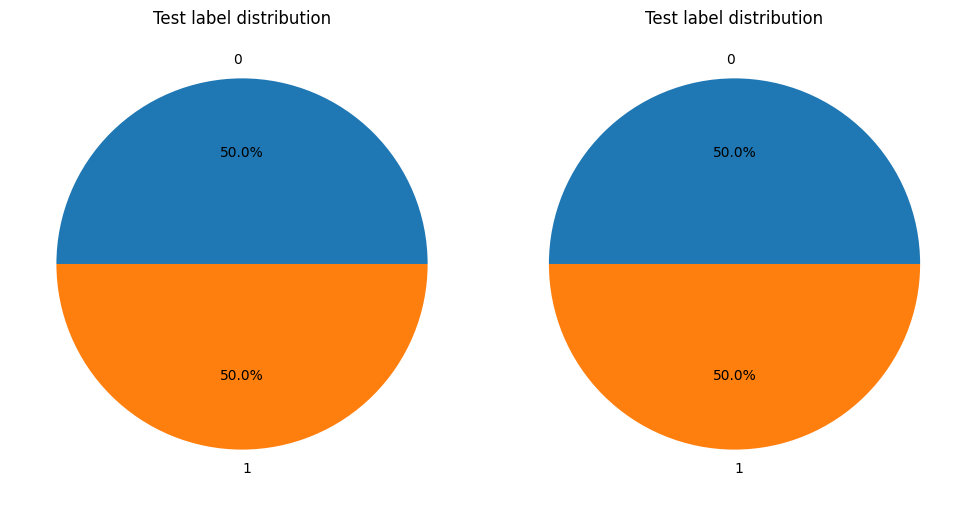

In [47]:
import matplotlib.pyplot as plt

# Count class distribution
train_counts = df_train['label'].value_counts().sort_index()
test_counts = df_test['label'].value_counts().sort_index()

# Create side-by-side pies
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%')
axes[0].set_title('Test label distribution')

axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%')
axes[1].set_title('Test label distribution')

plt.tight_layout()
plt.show()

# Imbalance (60-40) + subsampling

In [34]:
def make_imbalance(df, label_col="label", majority_label=1, ratio=0.60, n=560_000, seed=42):
    """
    ratio = udeo majority_label (npr 0.60 -> 60/40)
    n = ukupna veličina dataseta
    """
    df_major = df[df[label_col] == majority_label]
    df_minor = df[df[label_col] != majority_label]

    n_major = int(n * ratio)
    n_minor = n - n_major

    out = pd.concat([
        df_major.sample(n_major, random_state=seed),
        df_minor.sample(n_minor, random_state=seed),
    ], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)

    return out

In [39]:
df_train_sub = make_imbalance(df_train)

In [40]:
df_train_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 560000 entries, 0 to 559999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   560000 non-null  int64
 1   text    560000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 8.5 MB


In [42]:
df_test_sub = make_imbalance(df_test,n=38_000)

In [43]:
df_test_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   38000 non-null  int64
 1   text    38000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 593.9 KB


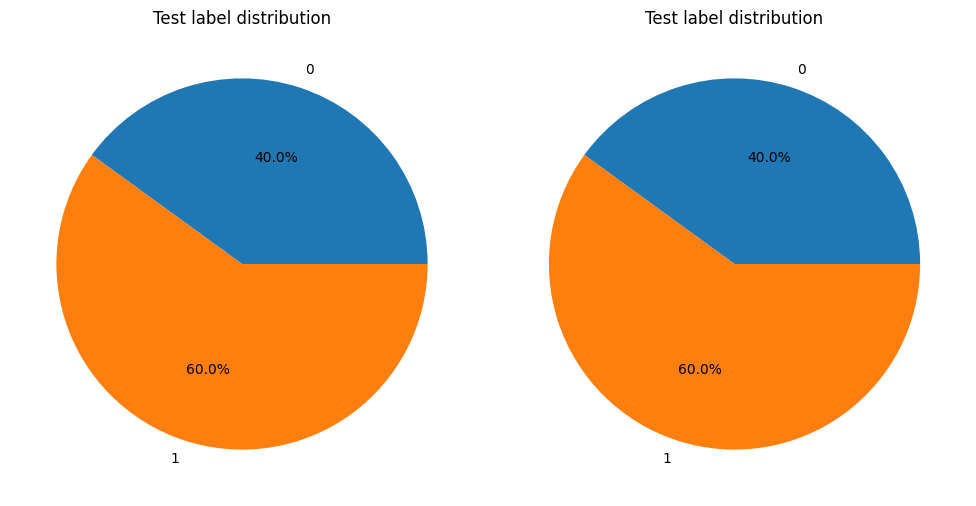

In [46]:
import matplotlib.pyplot as plt

# Count class distribution
train_counts = df_train_sub['label'].value_counts().sort_index()
test_counts = df_test_sub['label'].value_counts().sort_index()

# Create side-by-side pies
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(train_counts, labels=train_counts.index, autopct='%1.1f%%')
axes[0].set_title('Test label distribution')

axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%')
axes[1].set_title('Test label distribution')

plt.tight_layout()
plt.show()

In [48]:
df_train_sub.to_csv('amazon_reviews/train_sub.csv')
df_test_sub.to_csv('amazon_reviews/test_sub.csv')